# 02 — EDA Clean: IBM AML HI-Small (post-cleaning)

Validates the cleaning pipeline and produces the summary visual report
used in the README.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "data").exists() and PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

CLEAN_PATH = PROJECT_ROOT / "data" / "processed" / "transactions_clean.parquet"
REPORTS = PROJECT_ROOT / "reports"

print("Clean file:", CLEAN_PATH.exists(), f"({CLEAN_PATH.stat().st_size / 1e6:.1f} MB)")

Clean file: True (148.2 MB)


In [2]:
df = pd.read_parquet(CLEAN_PATH, engine="pyarrow")
print("Shape:", df.shape)
df.head()

Shape: (5078345, 11)


,timestamp,from_bank,from_account,to_bank,to_account,amount_received,receiving_currency,amount_paid,payment_currency,payment_format,is_laundering
0,2022-09-01,0121,8123FB9B0,0121,8123FB9B0,47.64,Saudi Riyal,47.64,Saudi Riyal,Reinvestment,0
1,2022-09-01,0025170,8095AF7C0,0025170,8095AF7C0,3917.42,Canadian Dollar,3917.42,Canadian Dollar,Reinvestment,0
2,2022-09-01,0025665,809A7D4B0,0024779,809189BA0,97.49,Canadian Dollar,97.49,Canadian Dollar,Credit Card,0
3,2022-09-01,032317,800D4E490,012004,800D4E750,13939.05,Euro,13939.05,Euro,Wire,0
4,2022-09-01,001024,800C8D9D0,001024,800C8D9D0,10.37,Euro,10.37,Euro,Reinvestment,0


## 1. Summary statistics

In [3]:
print("Timestamp range :", df["timestamp"].min(), "→", df["timestamp"].max())
print("Target rate     :", f"{(df['is_laundering'] == 1).mean() * 100:.4f}%")
print("Amount Paid p50 :", f"{df['amount_paid'].median():,.2f}")
print("Amount Paid p99 :", f"{df['amount_paid'].quantile(0.99):,.2f}")

Timestamp range : 2022-09-01 00:00:00 → 2022-09-18 16:18:00
Target rate     : 0.1019%
Amount Paid p50 : 1,414.54


Amount Paid p99 : 13,524,530.71


## 2. Amount distribution — clean

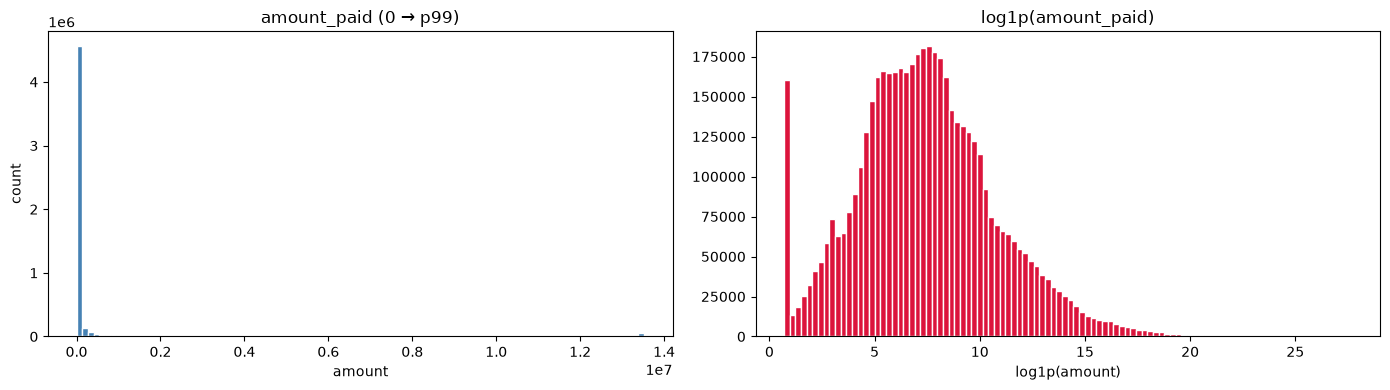

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].hist(df["amount_paid"].clip(lower=0, upper=df["amount_paid"].quantile(0.99)),
             bins=100, color="steelblue", edgecolor="white")
axes[0].set_title("amount_paid (0 → p99)")
axes[0].set_xlabel("amount")
axes[0].set_ylabel("count")

axes[1].hist(df["amount_paid"].clip(lower=1).pipe(lambda s: s[s > 0]).apply("log1p"),
             bins=100, color="crimson", edgecolor="white")
axes[1].set_title("log1p(amount_paid)")
axes[1].set_xlabel("log1p(amount)")
plt.tight_layout()
plt.savefig(REPORTS / "amount_distribution_clean.png", dpi=120, bbox_inches="tight")
plt.show()

## 3. Payment formats & currencies

In [5]:
print("Payment Format:")
print(df["payment_format"].value_counts())

print("\nPayment Currency:")
print(df["payment_currency"].value_counts())

Payment Format:
payment_format
Cheque          1864331
Credit Card     1323324
ACH              600797
Cash             490891
Reinvestment     481056
Wire             171855
Bitcoin          146091
Name: count, dtype: int64

Payment Currency:
payment_currency
US Dollar            1895172
Euro                 1168297
Swiss Franc           234860
Yuan                  213752
Shekel                192184
Rupee                 190202
UK Pound              180738
Yen                   155209
Ruble                 155178
Bitcoin               146066
Canadian Dollar       140042
Australian Dollar     136769
Mexican Peso          110159
Saudi Riyal            89014
Brazil Real            70703
Name: count, dtype: int64


## 4. Aggregate-level features (preview for Phase 4)

These are the kind of aggregates we will use for the model.

In [6]:
account_stats = df.groupby("from_account").agg(
    n_out=("amount_paid", "count"),
    total_out=("amount_paid", "sum"),
    mean_out=("amount_paid", "mean"),
).sort_values("n_out", ascending=False)

print("Top 5 most active source accounts:")
account_stats.head()

Top 5 most active source accounts:


,n_out,total_out,mean_out
from_account,,,
100428660,168672,5.276229e+10,3.128100e+05
1004286A8,103018,2.606938e+10,2.530565e+05
100428978,20497,7.532110e+09,3.674738e+05
1004286F0,18663,2.465736e+10,1.321189e+06
100428780,17264,3.739337e+11,2.165974e+07


In [7]:
print("\nDistribution of transaction count per account:")
print(account_stats["n_out"].describe())


Distribution of transaction count per account:
count    496995.000000
mean         10.218101
std         290.284113
min           1.000000
25%           1.000000
50%           2.000000
75%           5.000000
max      168672.000000
Name: n_out, dtype: float64
